# Stage 1: RNA and Protein Representation Analysis

This notebook investigates what pretrained nucleotide and protein models represent and how their representations relate to one another. The pilot uses nucleotide sequences and mRNA stability labels from `mRNA_Stability.csv`.

Each retained nucleotide sequence supplies two model inputs: its nucleotide sequence for Nucleotide Transformer and its translated amino acid sequence for ESM-2. Both encoders remain frozen during the analysis. Their parameters are not updated using the pilot dataset.

The protein input is derived by translation from the nucleotide input. The comparison therefore examines how two pretrained encoders represent related biological information.

## Research questions

- **Track A, Decodability:** Which properties can simple predictive models recover from the embeddings?
- **Track B, Cross-modal geometry:** How similarly do the two embedding spaces organize the same examples?
- **Track C, Attention analysis:** How does the selected attention summary relate to matches for RNA stability-associated sequence patterns?

## Role in the project

Stage 1 characterizes the representations available from the frozen encoders. Its observations inform the subsequent definition of alignment, development of fusion methods, and evaluation against single-modality baselines.

The analyses generate evidence and hypotheses for those later stages. Choosing an alignment objective or fusion architecture requires further controlled comparisons.

---

## Setup

### Imports

Imports are grouped by their role in the notebook.

In [1]:
# Standard library
import re

# Data handling and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

# Biological sequences and pretrained encoders
import torch
from Bio.Seq import Seq
from transformers import AutoModel, AutoTokenizer

# Statistical comparisons
from scipy.spatial.distance import pdist
from scipy.stats import mannwhitneyu, spearmanr

# Probes, dimensionality reduction, and evaluation
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GroupKFold, KFold, cross_val_score, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Analysis settings

These settings identify the input files, frozen encoders, and sample limits used in the pilot. Relative file paths assume the notebook runs with `Code` as its working directory.

`N_ROWS` controls the number of sampled rows before sequence filtering. The 1,000-row sample keeps the initial embedding workload manageable. Filtering can reduce the retained sample.

The encoder input limits are measured in tokens. The structural-proxy crop is measured in nucleotides.

`DEVICE` selects a CUDA GPU when available and otherwise uses the CPU. This affects execution time, particularly for embedding extraction and attention analysis.

In [2]:
SEED = 42
torch.manual_seed(SEED)

# Input files, relative to the Code directory
MAIN_CSV_PATH = "mRNA_Stability.csv"
CONTROL_CSV_PATH = "mRFP_Expression.csv"
SEQ_COLUMN = "Sequence"
LABEL_COLUMN = "Value"
LABEL_IS_CONTINUOUS = True

# Pilot sample size before sequence filtering
N_ROWS = 1000

# Frozen encoder checkpoints
RNA_MODEL_NAME = "InstaDeepAI/nucleotide-transformer-500m-human-ref"
PROTEIN_MODEL_NAME = "facebook/esm2_t12_35M_UR50D"

# Maximum tokenized input lengths used for embedding extraction
RNA_MAX_LEN = 1000
PROTEIN_MAX_LEN = 1024

# Additional analysis limits
LAYERWISE_N_ROWS = 200
STRUCTURE_N_ROWS = 200
STRUCTURE_CROP_LEN = 200  # nucleotides

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


### Reproducibility

Sampling, stochastic analyses, and PyTorch initialization use `SEED`, currently set to `42`. Individual NumPy generators receive this seed when constructed.

PyTorch initialization is seeded before loading the encoders. Evaluation mode and disabled gradient tracking are handled when the encoders are loaded and used.

Reproducing an experiment also requires the same data, model revisions, package versions, and analysis settings. A fixed seed alone does not guarantee identical results across environments.

---

## Model loading and embedding functions

The two helpers below provide the same loading and embedding procedure for both encoders. `load_encoder` prepares a tokenizer and model for reuse; `embed` converts one sequence into a vector that later analyses can use.

### Loading an encoder

`load_encoder(name)` loads the tokenizer and pretrained encoder associated with the supplied model name. It moves the model to `DEVICE` and returns the tokenizer and model together. Defining this function does not load either encoder; the later loading cell calls it for each checkpoint.

`model.eval()` switches layers with distinct training and evaluation behavior, such as dropout, into evaluation mode. It does not disable gradient tracking or set the model's parameters to `requires_grad=False`. The separate `@torch.no_grad()` decorator on `embed` disables gradient tracking during embedding extraction, avoiding the memory cost of recording operations for a backward pass. The encoders remain unchanged because this workflow does not perform training updates. See the PyTorch documentation for [evaluation mode](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html#torch.nn.Module.eval) and [gradient tracking](https://docs.pytorch.org/docs/2.14/generated/torch.no_grad.html).

### Producing a sequence embedding

`embed(seq, tok, model, max_len)` tokenizes one sequence, moves the resulting input tensors to `DEVICE`, and runs the encoder. `truncation=True` limits the tokenized input to `max_len`. Token counts follow the model's tokenizer and need not equal the number of nucleotides or amino acids in the original sequence. This function processes one sequence at a time and does not request padding. See the Transformers documentation for [padding and truncation](https://huggingface.co/docs/transformers/main/en/pad_truncation).

The encoder returns a final hidden-state vector for each token. The `last_hidden_state` array has shape `(1, T, d)`: one sequence, `T` token positions, and `d` embedding features per position. This follows the Transformers [model-output convention](https://huggingface.co/docs/transformers/main_classes/output).

Mean pooling averages the token vectors to produce one vector for the sequence:

$$
\mathbf{z}
=
\frac{1}{T}
\sum_{t=1}^{T}
\mathbf{h}_{t}.
$$

In this notation:

- $T$ is the number of token positions returned after tokenization and truncation, including any special tokens.
- $t$ identifies one of those positions.
- $\mathbf{h}_{t}$, read as "bold h sub t," is the final hidden-state vector at position $t$. Bold symbols represent vectors.
- $d$ is the number of features in each token vector and in the pooled sequence vector.
- $\mathbf{z}$ is the resulting sequence embedding.
- $\sum$ means to add the vectors across token positions. Dividing by $T$ takes their average, feature by feature.

For example, token vectors $(1, 3)$ and $(5, 7)$ would average to the sequence vector $(3, 5)$. This is an illustrative calculation, not a model output.

| Code step | Shape for these encoders | Meaning |
|---|---|---|
| `out.last_hidden_state` | `(1, T, d)` | One feature vector per token position. |
| `.mean(dim=1)` | `(1, d)` | Average over the token axis, retaining the batch axis. |
| `.squeeze()` | `(d,)` | Remove the singleton batch axis. |
| `.cpu().numpy()` | `(d,)` | Return the vector as a NumPy array on the CPU. |

Sequences with different token counts therefore produce vectors of the same size for a given encoder. The pooled output no longer retains separate token positions.

### Current pooling choice

The mean includes every returned token position, including special tokens added by the tokenizer. The pooling operation does not use a separate mask to exclude positions. This documents the current representation definition; excluding special tokens or changing the weighting would change the embeddings and require a separate methodological decision.


In [3]:
def load_encoder(name):
    """Load a matching tokenizer and encoder on DEVICE in evaluation mode."""
    tok = AutoTokenizer.from_pretrained(name, trust_remote_code=True)
    model = (
        AutoModel.from_pretrained(name, trust_remote_code=True)
        .to(DEVICE)
        .eval()
    )
    return tok, model


@torch.no_grad()
def embed(seq, tok, model, max_len=1024):
    """Mean-pool one sequence's final hidden state into a NumPy vector."""
    inputs = tok(
        seq,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    ).to(DEVICE)
    out = model(**inputs)

    token_embeddings = out.last_hidden_state  # (1, T, d)
    sequence_embedding = token_embeddings.mean(dim=1)  # (1, d)
    return sequence_embedding.squeeze().cpu().numpy()


## Sequence helper functions


These helpers prepare the two sequence forms used to build paired embeddings: a nucleotide sequence for the nucleotide encoder and an amino acid sequence for the protein encoder. The later dataset embedding function combines these operations and separately excludes translated proteins shorter than five amino acids.

### Checking the sequence length and start

`is_in_frame_and_starts_correctly(seq)` converts the string to uppercase, removes surrounding whitespace, and returns `True` only when its length is divisible by three and it begins with `ATG` or `AUG`. These are the DNA-letter and RNA-letter forms of the start codon accepted by this notebook.

Codons contain three nucleotides, so the length check is:

$$
L \bmod 3 = 0.
$$

Here, $L$ is the normalized string length, and $\bmod$ means the remainder after division. A 12-nucleotide sequence contains four complete codons and passes the length check; a 13-nucleotide sequence has one nucleotide left over and fails it. Passing the length check alone is insufficient: the starting letters must also match.

This is a preliminary filter. It does not validate the nucleotide alphabet, check for a terminal stop codon, or establish that the input is a complete biological coding sequence.

### Translating the sequence

`translate_cds(seq)` returns an amino acid string using Biopython's default standard genetic code. CDS stands for coding sequence. With `to_stop=True`, translation ends at the first in-frame stop codon, and the stop symbol is omitted. If there is no stop codon, all complete codons are translated. The call does not enable Biopython's separate `cds=True` validation. See the [Biopython translation documentation](https://biopython.org/docs/latest/api/Bio.Seq.html#Bio.Seq.Seq.translate).

Before translation, `len(seq) % 3` gives the number of trailing characters outside a complete codon. Subtracting that remainder identifies where to end the slice: an input of length 13 would be trimmed to length 12. In the current callers, surrounding whitespace has already been removed and the preceding length check requires a multiple of three, so this trimming normally removes nothing. It remains part of the helper's behavior when called independently.

### Converting RNA letters to DNA letters

`rna_to_dna(seq)` returns an uppercase string with every `U` replaced by `T`; for example, `AUGGCU` becomes `ATGGCT`. This changes the alphabet used to represent the nucleotide sequence. It does not translate the sequence into a protein or compute a complementary strand.

The notebook uses this DNA-letter form as input to the nucleotide encoder and in Track C's motif comparisons. Supporting both `ATG` and `AUG` in the initial check accommodates either input convention; it does not establish that both conventions occur in the CSV data.


In [4]:
def is_in_frame_and_starts_correctly(seq):
    """Check for a length divisible by three and an ATG or AUG start."""
    seq = seq.upper().strip()
    return len(seq) % 3 == 0 and seq.startswith(("ATG", "AUG"))


def translate_cds(seq):
    """Translate complete codons using the standard code, up to the first stop."""
    trimmed_seq = seq[: len(seq) - (len(seq) % 3)]
    return str(Seq(trimmed_seq).translate(to_stop=True))


def rna_to_dna(seq):
    """Return an uppercase sequence with U replaced by T."""
    return seq.upper().replace("U", "T")

def get_seqs_for_kept_rows(df, seq_col):
    """Return normalized nucleotide sequences in retained input order.

    Repeat the normalization and retention rules used during embedding.
    Also used as the GroupKFold grouping key, so identical sequences
    always share a fold.
    """
    kept = []
    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()

        if not is_in_frame_and_starts_correctly(seq):
            continue
        if len(translate_cds(seq)) < 5:
            continue

        kept.append(seq)

    return kept


## Linear probing and representation similarity


These functions support two parts of Stage 1. A linear probe tests whether a target can be predicted from an embedding with a simple model. Linear centered kernel alignment (CKA) compares the similarity structure of two representations. Both operate on embeddings already produced by the frozen encoders.

### Linear probing

`run_probe(X, y, continuous, name)` expects `X` with shape `(n, p)`: one row per example and one column per feature. The target `y` contains one value per row in the same order. The function selects a model and scoring rule, evaluates it, and prints a summary; it does not return a fitted model.

#### Standardization and model choice

`StandardScaler` centers each feature and divides it by its standard deviation. For a feature with nonzero variance:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{s_j}.
$$

Here, $i$ identifies an example, $j$ identifies a feature, $x_{ij}$ is the original feature value, $\mu_j$ is that feature's mean, $s_j$ is its standard deviation, and $z_{ij}$ is the standardized value. The scaler uses a scale factor of one for a constant feature. The scaler is fit inside each training fold only; see [Leakage controls](#Leakage-controls) below. See [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

| Target | Model | Evaluation score |
|---|---|---|
| Continuous, such as a stability measurement | Ridge regression, with `RidgeCV` selecting the penalty strength | $R^2$ |
| Categorical | Logistic regression with `max_iter=2000` | Accuracy: the fraction of correctly predicted labels |

For continuous targets, the prediction is a weighted sum of standardized features plus an intercept:

$$
\hat{y}_i = \beta_0 + \sum_{j=1}^{p} \beta_j z_{ij}.
$$

The hat in $\hat{y}_i$ denotes a prediction. $\beta_0$, read as "beta zero," is the intercept; $\beta_j$ is the coefficient for feature $j$. Ridge regression chooses these coefficients by minimizing:

$$
\underbrace{\sum_{i \in \mathcal{T}} (y_i - \hat{y}_i)^2}_{\text{squared prediction error}}
+
\underbrace{\alpha \sum_{j=1}^{p} \beta_j^2}_{\text{coefficient penalty}}.
$$

$\mathcal{T}$ is the set of rows used to fit that model. The first term rewards accurate predictions on those rows. The second penalizes large coefficients, with $\alpha$ ("alpha") controlling its strength; the intercept is not penalized. Standardizing features makes their scales comparable when applying this penalty.

ISLR uses $\lambda$ ("lambda") for this tuning parameter; scikit-learn calls it `alpha`. The code supplies 20 candidate values spaced evenly on a logarithmic scale from $10^{-3}$ to $10^5$. ISLR, Section 6.2.1, explains ridge regression and its sensitivity to feature scaling; Section 6.2.3 explains selecting the penalty by cross-validation.

#### Evaluation and interpretation

The outer `cross_val_score` call fits and evaluates the full pipeline (scaler plus model) five times. Each fold is held out once while the other four folds are used for fitting. For the regression branch, `RidgeCV` additionally selects an alpha within each outer training subset. Its current defaults use efficient leave-one-out cross-validation with negative mean squared error as the selection score. This internal selection is distinct from the outer $R^2$ evaluation. See [RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html).

For a held-out fold $\mathcal{F}$ whose targets vary, the regression score is:

$$
R^2
=
1 -
\frac{\sum_{i \in \mathcal{F}} (y_i - \hat{y}_i)^2}
     {\sum_{i \in \mathcal{F}} (y_i - \bar{y}_{\mathcal{F}})^2}.
$$

$\bar{y}_{\mathcal{F}}$ is the mean observed target in that fold. The numerator measures the model's squared prediction error; the denominator measures the squared error of predicting that fold's mean. A score of one indicates perfect predictions, zero matches that reference error, and a negative score is worse. Held-out $R^2$ can therefore be negative, even though ISLR's introductory discussion considers a fitted least-squares model with an intercept. Constant targets need separate handling, as described in [scikit-learn's scoring documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html).

The printed value is the arithmetic mean of the five scores, followed by their standard deviation calculated with `scores.std()` (`ddof=0`). This describes variation across these folds; it is not a confidence interval or a standard error. When `groups` is supplied, the folds come from `GroupKFold(n_splits=5)`, which keeps every row sharing a group label in one fold; otherwise `cv=5` uses unshuffled `KFold` for regression and `StratifiedKFold` for classification. Neither uses a random seed. See [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).

A probe assesses information accessible to this model under this evaluation procedure. A weak score alone does not establish that the embedding contains no useful information.

#### Leakage controls

`StandardScaler` sits inside a scikit-learn `Pipeline` with the model, so each fold's scaling statistics come only from that fold's training rows; held-out rows never influence preprocessing. See scikit-learn's [data-leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

The local CSV contains repeated sequence strings: 65,356 rows but 29,949 distinct sequences, and 8,928 sequence groups occur in more than one supplied `Split`. With the current seed and filters, the 981 retained rows represent 964 distinct sequences. Every probe call passes the retained sequence strings as `groups`, so identical sequences always land in the same fold and never appear on both sides of a split. The source of the repetition and its relation to the CSV's `Split` column have not been audited, and no deduplication is applied.

### Linear centered kernel alignment

`linear_cka(X, Y)` compares two representations of the same examples. `X` has shape `(n, p)` and `Y` has shape `(n, q)`; feature counts may differ, but corresponding rows must refer to the same example.

First, the function subtracts each column's mean across examples. Call the centered matrices $X_c$ and $Y_c$. Unlike the probe's standardization, this step does not divide features by their standard deviations.

The function then computes:

$$
\operatorname{CKA}(X, Y)
=
\frac{\left\|Y_c^\top X_c\right\|_F^2}
     {\left\|X_c^\top X_c\right\|_F
      \left\|Y_c^\top Y_c\right\|_F}.
$$

The notation connects to the code as follows:

| Notation or operation | Meaning |
|---|---|
| $\top$, written `.T` in NumPy | Transpose: exchange rows and columns. |
| Matrix multiplication, written `@` | Sum products along the shared dimension. |
| $\|A\|_F$ | Frobenius norm: square every entry of matrix $A$, add the squares, and take the square root. |
| $Y_c^\top X_c$, shape $(q, p)$ | Dot products between centered features in the two representations. |
| $X_c^\top X_c$ and $Y_c^\top Y_c$ | Within-representation feature dot products used for normalization. |

For example, a matrix with entries $1, 2, 2, 4$ has Frobenius norm $\sqrt{1^2 + 2^2 + 2^2 + 4^2} = 5$. The numerator uses the square of such a norm.

This feature-based calculation is equivalent to comparing the centered example-similarity matrices $X_c X_c^\top$ and $Y_c Y_c^\top$. The common HSIC normalization factor cancels in the CKA ratio, so the code names its unnormalized top term `numerator`.

For nonzero centered representations, linear CKA lies between zero and one in exact arithmetic. It is unchanged by orthogonal transformations, such as rotations and reflections, or by nonzero uniform scaling of either representation. Arbitrary changes of basis or separate scaling of individual features can change it. See [Kornblith et al. (2019), Section 3 and Table 1](https://proceedings.mlr.press/v97/kornblith19a/kornblith19a.pdf).

If either centered representation is entirely zero, the denominator is zero and CKA is undefined; the current helper has no special handling for this case. High CKA describes representational similarity. It does not by itself establish good target prediction or a benefit from combining the modalities.

### Statistical and course references

- James, Witten, Hastie, and Tibshirani, *An Introduction to Statistical Learning with Applications in R*, second edition: Section 3.1.3, p. 70 ($R^2$); Sections 5.1.2-5.1.3, pp. 200 and 203-204 (leave-one-out and k-fold cross-validation); Section 6.2.1, pp. 237-239 (ridge regression and scaling); Section 6.2.3, p. 250 (tuning). The local June 2023 corrected PDF was consulted. The [authors' book site](https://www.statlearning.com/) provides the book.
- UCF Machine Learning, *Week 04_Validation*, slides 5, 7, and 9: separating fitting, model selection, and evaluation, and rotating the held-out fold.
- UCF Machine Learning, *Data Preprocessing for Machine Learning*, slide 5: the role of feature scaling.
- UCF Capstone general lecture, *Overfitting and Regularization* (Yousefi, 2020), slides 19-20: the ridge penalty and selecting its strength by cross-validation.

The course decks provide explanatory context; the linked library documentation specifies the defaults used by this implementation. CKA's definition comes from its research reference.



In [5]:
def run_probe(X, y, continuous, name, groups=None):
    """Print the mean and standard deviation of five linear-probe scores.

    Standardization is fit inside a Pipeline, so only each fold's training
    rows set the scaling statistics. When `groups` is supplied (the retained
    sequence strings), GroupKFold keeps every row from a duplicate-sequence
    group in the same fold. Without groups, plain KFold/StratifiedKFold is used.
    """
    if continuous:
        model = RidgeCV(alphas=np.logspace(-3, 5, 20))
        scoring = "r2"
        metric_name = "R^2"
    else:
        model = LogisticRegression(max_iter=2000)
        scoring = "accuracy"
        metric_name = "accuracy"

    pipeline = Pipeline([("scale", StandardScaler()), ("model", model)])

    if groups is not None:
        cv = GroupKFold(n_splits=5)
        scores = cross_val_score(pipeline, X, y, cv=cv, groups=groups, scoring=scoring)
    else:
        scores = cross_val_score(pipeline, X, y, cv=5, scoring=scoring)

    print(
        f"  Linear probe on {name} embeddings, {metric_name} (5 fold): "
        f"{scores.mean():.3f} +/- {scores.std():.3f}"
    )


def linear_cka(X, Y):
    """Return linear CKA for representations with matching example rows."""
    X_centered = X - X.mean(axis=0, keepdims=True)
    Y_centered = Y - Y.mean(axis=0, keepdims=True)

    numerator = np.linalg.norm(Y_centered.T @ X_centered, ord="fro") ** 2
    norm_x = np.linalg.norm(X_centered.T @ X_centered, ord="fro")
    norm_y = np.linalg.norm(Y_centered.T @ Y_centered, ord="fro")
    return numerator / (norm_x * norm_y)


## Dataset embedding


The `embed_dataset` function turns rows of nucleotide sequences into paired nucleotide and protein embeddings. It is reused for the main dataset, where labels are requested, and the synonymous-recoding control, where the caller does not request labels.

The input DataFrame has already been loaded and sampled by the calling cell. This function processes its rows in their existing order, using the sequence helpers and embedding function defined above.

### From input rows to paired embeddings

For each row, the function:

1. Reads `seq_col` as a string, removes surrounding whitespace, and converts it to uppercase.
2. Applies the length/start check. A failing row is counted and skipped before translation.
3. Translates the sequence and skips it if the resulting protein has fewer than five amino acids. This rejection has its own counter.
4. Converts `U` to `T` for the nucleotide encoder and obtains its embedding using `RNA_MAX_LEN`.
5. Embeds the translated protein using `PROTEIN_MAX_LEN` and records the protein string.
6. Collects the row's label when `label_col` names an existing column.

Each retained row contributes one vector to each embedding list. The final `np.vstack` calls stack those vectors into matrices, with one row per retained example. The token limits remain the settings passed to `embed`; they do not change the sequence filters.

### Returned data and row correspondence

Let $m$ be the number of retained rows, $d_{\mathrm{RNA}}$ the nucleotide embedding dimension, and $d_{\mathrm{protein}}$ the protein embedding dimension. For $m > 0$, the return tuple contains:

| Position | Returned object | Shape or length |
|---|---|---|
| 1 | `rna_embeds`: nucleotide embedding matrix | `(m, d_RNA)` |
| 2 | `prot_embeds`: protein embedding matrix | `(m, d_protein)` |
| 3 | `protein_strings`: list of translated proteins | Length `m` |
| 4 | `labels`: target values, when collected | `(m,)` for scalar targets, or `None` when labels are not collected |

Position $i$ in each returned object refers to the same retained input row. Filtering preserves the relative input order. The original DataFrame index is not included in the return tuple, so this correspondence is positional.

For example, if the middle row of three input rows is rejected, the two returned embedding matrices and the protein list contain the first and third examples in that order. The label array follows the same order when labels are collected.

### Rejection reporting and existing edge cases

The summary reports failed length/start checks separately from proteins shorter than five amino acids. These counts describe successive filters: a row that fails the first check is not translated or counted again. A summary is printed whenever either counter is nonzero.

If `label_col` is omitted or absent from the DataFrame, the function returns `None` for labels while still producing embeddings. When the column exists, retained label values are copied without additional validation; missing target values can therefore remain in the returned array.

If no rows survive, the current interface returns two empty NumPy arrays with shape `(0,)`, an empty protein list, and `None` for labels. The usual matrix shapes in the table apply only when at least one row is retained.


In [6]:
def embed_dataset(
    df, rna_tok, rna_model, prot_tok, prot_model, seq_col, label_col=None
):
    """Embed retained rows from seq_col and optionally collect label_col.

    Return RNA embeddings, protein embeddings, protein strings, and labels,
    with corresponding entries in retained input order. Labels are None
    when none are collected.
    """
    rna_vectors = []
    protein_vectors = []
    protein_strings = []
    label_values = []
    collect_labels = label_col is not None and label_col in df.columns

    dropped_sequence_check = 0
    dropped_short_protein = 0

    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()

        if not is_in_frame_and_starts_correctly(seq):
            dropped_sequence_check += 1
            continue

        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            dropped_short_protein += 1
            continue

        rna_vectors.append(
            embed(rna_to_dna(seq), rna_tok, rna_model, max_len=RNA_MAX_LEN)
        )
        protein_vectors.append(
            embed(protein_seq, prot_tok, prot_model, max_len=PROTEIN_MAX_LEN)
        )
        protein_strings.append(protein_seq)

        if collect_labels:
            label_values.append(row[label_col])

    if dropped_sequence_check or dropped_short_protein:
        print(
            f"  Dropped sequences: {dropped_sequence_check} failed length/start checks; "
            f"{dropped_short_protein} translated to fewer than 5 amino acids."
        )

    rna_embeds = np.vstack(rna_vectors) if rna_vectors else np.empty((0,))
    prot_embeds = np.vstack(protein_vectors) if protein_vectors else np.empty((0,))
    labels = np.array(label_values) if label_values else None
    return rna_embeds, prot_embeds, protein_strings, labels


---

## Load the encoders


The cell below calls `load_encoder` for each checkpoint selected in Setup. Each call returns a tokenizer and its matching model, which are retained for the later embedding cells.

| Configuration setting | Returned objects | Role |
|---|---|---|
| `RNA_MODEL_NAME` | `rna_tok`, `rna_model` | Tokenizer and encoder for the nucleotide-sequence branch. |
| `PROTEIN_MODEL_NAME` | `prot_tok`, `prot_model` | Tokenizer and encoder for the translated-protein branch. |

The `rna_*` names identify the nucleotide branch used for the source sequences; those sequences are converted to DNA letters before embedding. The shared `load_encoder` helper places each model on `DEVICE` and sets evaluation mode, as explained in the earlier helper section.

Loading may download tokenizer and checkpoint files from Hugging Face. Matching files already in the local cache can be reused, although model initialization and transfer to `DEVICE` still take time. See the Transformers [cache documentation](https://huggingface.co/docs/transformers/installation#cache-directory).

This cell prepares both tokenizer/model pairs. Sequence embedding occurs in the following section.


In [7]:
rna_tok, rna_model = load_encoder(RNA_MODEL_NAME)
prot_tok, prot_model = load_encoder(PROTEIN_MODEL_NAME)
print("Encoders loaded.")

Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-human-ref and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Encoders loaded.


### Interpreting the loading messages

The loading output above reports the same message for both checkpoints:

| Parameter names in the report | Status | Interpretation |
|---|---|---|
| `pooler.dense.weight` and `pooler.dense.bias` | Newly initialized | The instantiated model expects these pooler parameters, but the checkpoint does not contain them, so they were randomly initialized. |

The `embed` helper computes its own mean over `last_hidden_state`. It does not use the model's separate `pooler_output`, so these randomly initialized pooler weights never enter the embeddings used in this notebook. See the [ESM output definitions](https://huggingface.co/docs/transformers/main/en/model_doc/esm). The accompanying "You should probably TRAIN this model" line is a generic Transformers notice triggered by any newly initialized weight; it does not apply to this frozen, mean-pooled use. See the Transformers [loading-warning definitions](https://huggingface.co/docs/transformers/main_classes/model).

The final `Encoders loaded.` message is printed after both calls to `load_encoder` return. It confirms completion of those loading calls; successful embedding extraction and downstream analysis must be checked separately.


## Embed the main dataset (mRNA_Stability)


This cell creates the paired embeddings and stability labels used by the main-dataset analyses. It uses the tokenizer/model pairs loaded above and the shared `embed_dataset` helper.

The pipeline is:

1. Load `MAIN_CSV_PATH` and drop rows missing a value in `SEQ_COLUMN`.
2. Sample `N_ROWS` rows without replacement using `SEED`. The current setting requests 1,000 rows before the helper applies its sequence filters. With the same input rows, row order, and software environment, the seed makes this sample repeatable. See the [pandas sampling documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).
3. Pass the sampled rows to `embed_dataset`, which applies the length/start and minimum protein-length checks described above. Retained rows produce `rna_embeds`, `prot_embeds`, and labels from `LABEL_COLUMN` in corresponding order. The returned protein strings are assigned to `_` and are not used in this section.
4. Report how many sampled rows were embedded and save the resulting arrays.

`main_df` remains the sampled DataFrame, including rows subsequently rejected by the helper. The embedding arrays contain only retained rows, so they can be shorter than `main_df`. This sampling step does not use the CSV's `Split` column; it does not establish separate training, validation, or test sets.

The `np.savez` call writes `stage1_main_embeddings.npz` in the current working directory with three keys: `rna`, `protein`, and `labels`. If no labels were collected, the saved `labels` entry is an empty array. Protein strings are not saved. This notebook has no cache-loading branch: rerunning the cell performs embedding again and overwrites the archive. The saved arrays could be loaded separately for later work. See the [NumPy archive documentation](https://numpy.org/doc/stable/reference/generated/numpy.savez.html).


In [8]:
main_df = (
    pd.read_csv(MAIN_CSV_PATH)
    .dropna(subset=[SEQ_COLUMN])
    .sample(n=N_ROWS, random_state=SEED)
)
rna_embeds, prot_embeds, _, labels = embed_dataset(
    main_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN, LABEL_COLUMN
)
print(f"Embedded {len(rna_embeds)} of {len(main_df)} sampled sequences.")

# Retained sequence strings, used by every probe below as the GroupKFold
# grouping key.
kept_seqs = get_seqs_for_kept_rows(main_df, SEQ_COLUMN)

np.savez(
    "stage1_main_embeddings.npz",
    rna=rna_embeds,
    protein=prot_embeds,
    labels=labels if labels is not None else np.array([]),
)


  Dropped sequences: 19 failed length/start checks; 0 translated to fewer than 5 amino acids.
Embedded 981 of 1000 sampled sequences.


### Inspect the output shapes

The following cell prints the dimensions of the arrays just produced. When at least one row is retained, each embedding shape is `(retained rows, embedding width)`, and the scalar stability labels should have shape `(retained rows,)`. A label shape of `None` means the helper did not collect labels. If no rows survive, the helper's existing empty-array behavior is described in the dataset-embedding section above.

These prints support manual inspection; they do not assert expected widths, verify row correspondence, or check label completeness and finite values. Matching dimensions alone do not establish that the encoders or resulting representations are suitable for the research question.


In [9]:
print("RNA embedding shape:", rna_embeds.shape)
print("Protein embedding shape:", prot_embeds.shape)
print("Label shape:", labels.shape if labels is not None else None)


RNA embedding shape: (981, 1280)
Protein embedding shape: (981, 480)
Label shape: (981,)


---

## Representation analysis

With paired embeddings available, Stage 1 examines what these representations make accessible to downstream analyses. The encoders remain fixed; the analyses fit probes, compare representation spaces, or inspect model behavior.

| Track | Main question |
|---|---|
| A: Decodability | Can a linear probe predict stability or a sequence property from an embedding? |
| B: Cross-modal geometry | How do the RNA and protein representation spaces relate, and how does a simple combined representation perform? |
| C: Interpretability | What do attention patterns, sequence motifs, and alignment diagnostics suggest about model behavior? |

The first comparison establishes RNA-only and protein-only stability baselines for the later analyses.


### Track A: Decodability

#### Stability prediction with linear probes


This is the Stage 1 preview of Mina's RNA-versus-protein comparison. Two calls to `run_probe` assess stability prediction from `rna_embeds` and `prot_embeds` separately, using the same retained examples and `labels` in corresponding order. The probes are fitted on these representations; the encoders are not fine-tuned.

With the current `LABEL_IS_CONTINUOUS = True` setting, each call uses ridge regression and reports the mean $R^2$ and standard deviation of five outer-fold scores. The shared helper supplies the model settings and internal penalty selection. See [Linear probing](#Linear-probing) above for the equations, symbols, and evaluation procedure.

Both calls pass `groups=kept_seqs`, so they use the same `GroupKFold` outer folds, with identical sequences kept together. No additional seed is needed in this cell. See [scikit-learn's splitting rules](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html). ISLR Section 5.1.3 and the course's Week 04 Validation slides 5, 7, and 9 provide the cross-validation context; their source details are listed in [Statistical and course references](#Statistical-and-course-references) above.

The guard checks only that `labels` is not `None` and its length matches the number of RNA embeddings. If either check fails, the cell prints a message and skips both probes. It does not check the protein row count, row identities, missing or non-finite labels, or whether enough rows are available for cross-validation. Passing the guard therefore does not guarantee that fitting will succeed.


In [10]:
if labels is not None and len(labels) == len(rna_embeds):
    print("Linear probing: RNA-only versus protein-only.")
    run_probe(rna_embeds, labels, LABEL_IS_CONTINUOUS, "RNA", groups=kept_seqs)
    run_probe(prot_embeds, labels, LABEL_IS_CONTINUOUS, "protein", groups=kept_seqs)
else:
    print(
        "Skipping linear probing: labels are absent or their count does not "
        "match the RNA embeddings."
    )


Linear probing: RNA-only versus protein-only.
  Linear probe on RNA embeddings, R^2 (5 fold): 0.015 +/- 0.072
  Linear probe on protein embeddings, R^2 (5 fold): 0.103 +/- 0.034


**Results.**

| Representation | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA | 0.015 | 0.072 |
| Protein | 0.103 | 0.034 |

Protein embeddings predict stability better than RNA embeddings. The protein mean sits about three fold standard deviations above zero, while the RNA mean is small relative to its fold spread, so these folds show no reliable linear stability signal in the RNA embeddings. The difference between the two means is not itself a significance test.

The standard deviations describe variation among the five fold scores. They are not confidence intervals or significance tests. The helper prints summaries without returning the individual fold scores.


#### Sequence-length baseline


This baseline predicts stability from one feature: the full input-sequence length in nucleotides. Comparing it with the RNA and protein probes asks how much predictive value is available from this simple sequence property alone.

`get_lengths_for_kept_rows` repeats the sequence filters used during embedding and preserves the retained rows' order in `main_df`. It returns `seq_lengths` with shape `(n, 1)`: one row per retained example and one feature column. Correspondence with `labels` depends on using the same sampled dataframe and filtering helpers as the embedding step; this cell does not verify row identities.

Length is measured after stripping surrounding whitespace and uppercasing. It is the full input-sequence length, not translated protein length, token count, or the truncated length seen by an encoder. Translation determines whether a row is retained but does not shorten the sequence being measured.

The call reuses `run_probe`; with the current continuous-target setting, it fits ridge regression and reports the mean and standard deviation of five outer-fold $R^2$ scores. See [Linear probing](#Linear-probing) for the equations and ISLR-backed evaluation explanation. The length calculation is deterministic and needs no additional seed.


In [11]:
def get_lengths_for_kept_rows(df, seq_col):
    """Return full nucleotide-sequence lengths with shape (n, 1).

    Repeat the embedding filters and preserve retained input order.
    """
    lengths = []
    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()

        if not is_in_frame_and_starts_correctly(seq):
            continue

        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            continue

        lengths.append(len(seq))

    return np.array(lengths).reshape(-1, 1)


seq_lengths = get_lengths_for_kept_rows(main_df, SEQ_COLUMN)
print("Length-only baseline: predict stability from sequence length.")
run_probe(seq_lengths, labels, LABEL_IS_CONTINUOUS, "sequence length only", groups=kept_seqs)


Length-only baseline: predict stability from sequence length.
  Linear probe on sequence length only embeddings, R^2 (5 fold): -0.006 +/- 0.013


**Result.**

| Feature | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| Sequence length | −0.006 | 0.013 |

Length alone has no linear predictive value for stability: the mean is slightly below zero, meaning it does no better than predicting each fold's mean. The standard deviation describes variation among the five fold scores; it is not a confidence interval or a significance test.

This result does not establish that the embedding probes are free of length-related confounding: nonlinear length effects or interactions with composition could still matter.


#### GC-content prediction


These probes ask how well the RNA and protein embeddings predict the GC fraction of their source nucleotide sequence. The target is calculated directly from the sequence; it is not the dataset's stability label used in the preceding probes.

For a sequence $s$, GC content is:

$$
\mathrm{GC}(s) = \frac{N_G(s) + N_C(s)}{L(s)}.
$$

$N_G(s)$ and $N_C(s)$ count G and C bases, and $L(s)$ is the full sequence length. The result is a fraction between zero and one. For example, `GCAU` contains two G-or-C bases among four nucleotides, giving $2/4 = 0.5$, or 50% GC.

`kept_seqs`, built in the main embedding cell by `get_seqs_for_kept_rows`, repeats the normalization and retention rules used during embedding and preserves retained input order. The same list supplies the probe grouping key and the inputs for the later GC3, structure, and attention analyses. Correspondence with the embeddings depends on using the same input rows in the same order, with unchanged normalization and retention rules; the helper does not verify row identities.

`gc_content` expects a nonempty uppercase sequence. It divides the G-plus-C count by the full string length, without independently validating the nucleotide alphabet. The target uses the full retained sequence, including any sequence after the first translated stop; it is not cropped to the encoder's input limit.

`seq_gc` stores one continuous target per retained example, with shape `(n,)`. Both calls to `run_probe` use this same target array, first with `rna_embeds` and then with `prot_embeds`. The `True` argument selects continuous-target regression. See [Linear probing](#Linear-probing) for the ridge model, cross-validation, and ISLR references. Computing GC content is deterministic and needs no additional seed.


In [12]:
def gc_content(seq):
    """Return the G-or-C fraction of a nonempty uppercase sequence."""
    return (seq.count("G") + seq.count("C")) / len(seq)


seq_gc = np.array([gc_content(s) for s in kept_seqs])

print("GC-content prediction from RNA embeddings.")
run_probe(rna_embeds, seq_gc, True, "RNA (predicting GC content)", groups=kept_seqs)
print("\nGC-content prediction from protein embeddings.")
run_probe(prot_embeds, seq_gc, True, "protein (predicting GC content)", groups=kept_seqs)


GC-content prediction from RNA embeddings.
  Linear probe on RNA (predicting GC content) embeddings, R^2 (5 fold): 0.986 +/- 0.002

GC-content prediction from protein embeddings.
  Linear probe on protein (predicting GC content) embeddings, R^2 (5 fold): 0.678 +/- 0.042


**Results.**

| Representation | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA | 0.986 | 0.002 |
| Protein | 0.678 | 0.042 |

GC composition is almost perfectly recoverable from the nucleotide embeddings, and the translated-protein embeddings also predict a substantial part of its variation. The standard deviations describe variation among five fold scores; they are not confidence intervals or a significance test of the RNA–protein difference.

The protein result is compatible with associations between amino-acid composition and source-sequence GC content. It does not establish the mechanism behind that association or show recovery of exact synonymous-codon choices. Predicting GC composition also does not establish predictive performance for stability or validate every biological interpretation.


#### GC3 prediction


This probe asks whether the embeddings make third-position nucleotide composition linearly recoverable. GC3 is the fraction of complete codons whose third base is G or C. It is related to synonymous codon usage, but it is not a complete measure of codon bias, codon optimality, or translation efficiency. There is no universal 50% GC3 reference against which bias can be declared.

For a sequence $s$ grouped into codons from its first base:

$$
\mathrm{GC3}(s)
= \frac{N_{G,3}(s) + N_{C,3}(s)}{N_{\mathrm{codons}}(s)}.
$$

$N_{G,3}(s)$ and $N_{C,3}(s)$ count complete codons with G or C at their third position, and $N_{\mathrm{codons}}(s)$ is the number of complete codons. For example, `AUG | GCC | AAA` has third bases `G, C, A`, so GC3 is $2/3$, approximately 0.667.

`gc3_content` selects those bases with `seq[2::3]`: Python indices 2, 5, 8, and so on correspond to nucleotide positions 3, 6, 9. It then reuses `gc_content` from the preceding cell. Any incomplete trailing codon contributes no third base. The helper expects an uppercase sequence with at least one complete codon; it does not add normalization or alphabet validation. See [Python's slicing rules](https://docs.python.org/3/builtins/stdtypes.html#common-sequence-operations).

The calculation uses the full retained input sequence, including complete codons after any translated stop or beyond the encoder's input limit. `kept_seqs` supplies the same retained order as in the preceding GC analysis; the earlier filters do not establish experimentally verified complete coding sequences. `seq_gc3` contains one continuous target per row. The two calls reuse the existing [linear-probe procedure](#Linear-probing), and the calculation needs no additional seed.

GC3 should also be distinguished from other codon-usage measures. The Codon Adaptation Index uses a reference set, whereas measures such as [Wright's effective number of codons (1990)](https://pubmed.ncbi.nlm.nih.gov/2110097/) can be calculated from a sequence alone. This cell calculates GC3 only.

Finally, `np.corrcoef(seq_gc, seq_gc3)[0, 1]` reports the [Pearson correlation](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between overall GC and GC3 across the retained examples. It describes their linear association, not a probe $R^2$ or representation-alignment score. Strong association indicates overlap between these composition targets; it does not establish whether GC3 adds predictive value beyond overall GC.


In [13]:
def gc3_content(seq):
    """Return the GC fraction at third positions of complete codons."""
    third_positions = seq[2::3]
    return gc_content(third_positions)


seq_gc3 = np.array([gc3_content(s) for s in kept_seqs])

print("GC3 prediction from RNA embeddings.")
run_probe(rna_embeds, seq_gc3, True, "RNA (predicting GC3)", groups=kept_seqs)
print("\nGC3 prediction from protein embeddings.")
run_probe(prot_embeds, seq_gc3, True, "protein (predicting GC3)", groups=kept_seqs)

gc3_gc_corr = np.corrcoef(seq_gc, seq_gc3)[0, 1]
print(
    f"\nPearson correlation between overall GC content and GC3: {gc3_gc_corr:.3f}"
)


GC3 prediction from RNA embeddings.
  Linear probe on RNA (predicting GC3) embeddings, R^2 (5 fold): 0.969 +/- 0.003

GC3 prediction from protein embeddings.
  Linear probe on protein (predicting GC3) embeddings, R^2 (5 fold): 0.380 +/- 0.056

Pearson correlation between overall GC content and GC3: 0.922


**Results.**

| Representation | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA | 0.969 | 0.003 |
| Protein | 0.380 | 0.056 |

The Pearson correlation between overall GC and GC3 is $r = 0.922$, a strong positive association between these sequence-derived targets. This correlation does not measure the additional predictive value of GC3 after accounting for overall GC.

RNA has the higher GC3-probe score, and the RNA–protein gap is larger than in the overall-GC probe (0.969 vs. 0.380 here, against 0.986 vs. 0.678 for GC). That pattern is consistent with translation removing exact synonymous-codon identity. These comparisons do not independently establish that mechanism or recovery of codon usage in general.

The standard deviations describe variation among five fold scores; they are not confidence intervals or significance tests.


#### Secondary-structure proxy: Nussinov pairing fraction


This probe predicts a simplified folding score: the largest fraction of nucleotides that can participate in permitted, noncrossing pairs within a sequence prefix. The Nussinov-style calculation maximizes a pair count; it does not estimate thermodynamic free energy or measure an experimental structure. See [Nussinov and Jacobson (1980)](https://pubmed.ncbi.nlm.nih.gov/6161375/).

**Pairing rules.** `can_pair` accepts A–U, G–C, and G–U in either order, plus A–T and G–T for DNA-letter inputs. Each position can participate in at most one pair. Nested pairs are allowed; crossing pairs are excluded. Inputs are already uppercase in this pipeline; the helpers do not independently normalize or validate the sequence.

For a candidate pair at positions $i$ and $k$, the minimum separation is:

$$
k - i - 1 \geq m.
$$

Here, $m$ is `min_loop`, a nonnegative integer with default three. The pair must enclose at least $m$ sequence positions. Those positions are not all required to be unpaired: nested pairs may occupy the enclosed interval.

**Dynamic program.** Let $D(i,j)$ be the maximum permitted pair count within the inclusive interval from position $i$ through $j$. In code, this is `max_pairs[i][j]`. The algorithm fills shorter intervals before longer ones, so the smaller problems are already solved when needed. For each interval it compares two choices:

1. Leave position $i$ unpaired and use the best count for $i+1$ through $j$.
2. Pair $i$ with an eligible position $k$. Count that pair, then add the best counts inside the pair and in the remaining sequence after $k$.

Write $\mathcal{K}(i,j)$ for positions $k$ that are no later than $j$, satisfy the minimum separation, and can pair with the base at $i$. The comparison is:

$$
D(i,j)
= \max\left\{
D(i+1,j),
\max_{k \in \mathcal{K}(i,j)}
\left[1 + D(i+1,k-1) + D(k+1,j)\right]
\right\}.
$$

The three terms inside the brackets are the new pair, the pairs inside it (`inside_pairs`), and the pairs after it (`remaining_pairs`). If no eligible $k$ exists, only the unpaired choice applies. Empty intervals and intervals too short for an eligible pair contribute zero. The routine returns the optimal fraction rather than reconstructing a list of pairs.

**Pairing fraction.** For a nonempty input of length $n$, the maximum pair count is $P_{\max}=D(0,n-1)$. Each pair uses two nucleotides, so:

$$
f_{\mathrm{paired}} = \frac{2P_{\max}}{n}.
$$

Here, $n$ is the actual prefix length supplied to the helper. For example, `AAAAU` with `min_loop=3` permits the first and last bases to pair, enclosing three positions. One pair occupies two of five nucleotides, giving $f_{\mathrm{paired}}=2/5=0.4$. Inputs too short to contain an eligible pair return zero before the division.

**Sampling and probe inputs.** The calculation takes $O(n^3)$ time and $O(n^2)$ memory. The current settings sample 200 retained row indices without replacement and score up to the first 200 nucleotides of each selected sequence. Distinct row indices need not contain distinct sequences. The [sampling call](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html) requires at least the requested number of retained rows.

`default_rng(SEED)` uses the existing seed. Repeating the selection assumes unchanged retained rows, row order, settings, and compatible software behavior. Sorting the selected indices restores retained input order, which also determines the current unshuffled probe folds. The same indices select both embedding matrices, keeping them aligned with `pairing_scores`.

Only the target calculation uses the cropped prefix. The cell reuses existing embeddings for those rows; it does not re-encode the prefixes. A supplied prefix is not necessarily a verified 5′ UTR or the full transcript. Both calls use the existing [linear-probe procedure](#Linear-probing), grouped by sequence.



In [14]:
def can_pair(a, b):
    """Return whether two uppercase bases form an allowed RNA or T-equivalent pair."""
    pair = {a, b}
    return pair in ({"A", "U"}, {"A", "T"}, {"G", "C"}, {"G", "U"}, {"G", "T"})


def nussinov_pairing_fraction(seq, min_loop=3):
    """Return the maximum paired-nucleotide fraction under noncrossing pairing.

    Expect an uppercase sequence and a nonnegative integer min_loop.
    Each pair must enclose at least min_loop sequence positions.
    """
    n = len(seq)
    if n < min_loop + 2:
        return 0.0

    # Each entry covers the inclusive interval from i through j.
    max_pairs = [[0] * n for _ in range(n)]
    for span in range(min_loop + 1, n):
        for i in range(0, n - span):
            j = i + span

            # First consider leaving position i unpaired.
            best_pair_count = max_pairs[i + 1][j]

            # Then consider eligible partners, enforcing the minimum separation.
            for k in range(i + min_loop + 1, j + 1):
                if can_pair(seq[i], seq[k]):
                    inside_pairs = max_pairs[i + 1][k - 1] if k - 1 >= i + 1 else 0
                    remaining_pairs = max_pairs[k + 1][j] if k + 1 <= j else 0
                    candidate_pairs = inside_pairs + 1 + remaining_pairs
                    if candidate_pairs > best_pair_count:
                        best_pair_count = candidate_pairs

            max_pairs[i][j] = best_pair_count

    return (2 * max_pairs[0][n - 1]) / n


rng = np.random.default_rng(SEED)
structure_idx = rng.choice(len(kept_seqs), size=STRUCTURE_N_ROWS, replace=False)
structure_idx.sort()

pairing_scores = np.array(
    [
        nussinov_pairing_fraction(kept_seqs[idx][:STRUCTURE_CROP_LEN])
        for idx in structure_idx
    ]
)

rna_struct_embeds = rna_embeds[structure_idx]
prot_struct_embeds = prot_embeds[structure_idx]
structure_groups = [kept_seqs[i] for i in structure_idx]

print(
    f"Nussinov pairing-fraction prediction on {STRUCTURE_N_ROWS} rows, "
    f"using up to {STRUCTURE_CROP_LEN} nucleotides per sequence:"
)
run_probe(
    rna_struct_embeds,
    pairing_scores,
    True,
    "RNA (predicting Nussinov pairing fraction)",
    groups=structure_groups,
)
run_probe(
    prot_struct_embeds,
    pairing_scores,
    True,
    "protein (predicting Nussinov pairing fraction)",
    groups=structure_groups,
)


Nussinov pairing-fraction prediction on 200 rows, using up to 200 nucleotides per sequence:
  Linear probe on RNA (predicting Nussinov pairing fraction) embeddings, R^2 (5 fold): 0.089 +/- 0.033
  Linear probe on protein (predicting Nussinov pairing fraction) embeddings, R^2 (5 fold): 0.093 +/- 0.055


**Results.**

| Representation | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA | 0.089 | 0.033 |
| Protein | 0.093 | 0.055 |

Both embeddings predict the pairing fraction only weakly, and at about the same level. The RNA encoder, despite reading the nucleotides directly, shows no advantage over the protein encoder on this folding proxy. The standard deviations describe variation among five fold scores on 200 rows; they are not confidence intervals or significance tests.

This cropped maximum-pairing score measures a narrow proxy, so a weak linear probe does not show that the encoder contains no RNA-structure information.


---
### Track B: Cross-modal geometry

#### Stability prediction from concatenated embeddings


Track B begins with a predictive baseline before its geometry comparisons. This baseline gives the stability probe both representations of each example and asks whether they improve prediction over either representation alone.

**Concatenation appends feature columns.** Let $X_{\mathrm{RNA}}$ have shape $(n, p)$ and $X_{\mathrm{protein}}$ have shape $(n, q)$, where $n$ is the number of retained examples and $p$ and $q$ are the respective embedding widths. The combined matrix is

$$
X_{\mathrm{concat}}
=
\left[X_{\mathrm{RNA}} \;\; X_{\mathrm{protein}}\right]
\in \mathbb{R}^{n \times (p+q)}.
$$

For one example, concatenating an RNA vector `[0.2, 0.4]` and a protein vector `[0.7]` produces `[0.2, 0.4, 0.7]`. The number of examples stays the same; each row now contains both sets of features. This operation does not average or align their coordinates.

The code uses `np.hstack` and passes the combined matrix to the existing [linear probe](#Linear-probing). With the current continuous-target setting, this reuses ridge regression and the existing five-fold evaluation. Both embedding matrices and the stability labels must correspond to the same examples in the same row order; matching dimensions alone do not establish that correspondence. This cell assumes usable, aligned labels.

The protein sequence is derived deterministically from the same coding sequence, rather than being an independent protein measurement. Its pretrained encoder may expose complementary predictive features. A reliable gain under a controlled evaluation could support that complementarity, but would not by itself establish biological synergy. Concatenation itself is deterministic and introduces no learned fusion layer.


In [15]:
concat_embeds = np.hstack([rna_embeds, prot_embeds])

print("Stability prediction from concatenated RNA and protein embeddings.")
run_probe(
    concat_embeds,
    labels,
    LABEL_IS_CONTINUOUS,
    "RNA + protein (concatenated)",
    groups=kept_seqs,
)


Stability prediction from concatenated RNA and protein embeddings.
  Linear probe on RNA + protein (concatenated) embeddings, R^2 (5 fold): 0.100 +/- 0.048


**Results.** The first two rows repeat the Track A stability probes so all three inputs can be compared.

| Probe input | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA embeddings | 0.015 | 0.072 |
| Protein embeddings | 0.103 | 0.034 |
| Concatenated RNA and protein embeddings | 0.100 | 0.048 |

Concatenation scores 0.100 against 0.103 for protein alone, so adding the RNA features gives no gain under a linear probe. Fold standard deviations describe variation across folds; they are neither confidence intervals nor a paired uncertainty estimate for the difference.

This is the concatenation baseline. A missing gain does not rule out useful complementarity, and it does not show that cross-attention or another learned fusion module will improve performance. Those are questions for controlled comparisons.


# Stage 1, Track B: Cross-Modal Geometry, CKA

The first Track B geometry metric: a single linear CKA score between the full RNA and protein embedding spaces, using the linear_cka function defined above, computed once on the complete final-layer pooled embeddings for all 981 sequences. This is a population-level, whole-space comparison, unlike the per-sample linear probes above, and answers a different question, not whether either space contains stability signal, but whether the two spaces are structured similarly to each other in general.

In [16]:
print("Linear CKA, RNA vs protein:", f"{linear_cka(rna_embeds, prot_embeds):.3f}")

Linear CKA, RNA vs protein: 0.128


CKA of 0.128 indicates the two embedding spaces are, taken as a whole, structured quite differently from each other rather than being redundant copies of the same information. Combined with the synergy check above, this is a reasonable place to be: the two modalities are not simply duplicating each other, though that alone does not guarantee a fusion module will find something useful to combine, it only rules out the case where fusion would obviously be pointless.

# Stage 1, Track B: Cross-Modal Geometry, Layer-wise CKA

Extends the single final-layer CKA number into a full picture across every internal layer of both encoders, not just their final output, since prior work on cross-modal alignment shows the strongest alignment often shows up mid-network rather than at the final layer. embed_all_layers is a variant of embed above that requests output_hidden_states=True and returns every layer's mean-pooled representation rather than only the last one. embed_dataset_all_layers runs that across a 200-sequence subsample, LAYERWISE_N_ROWS, rather than the full 981, purely for speed, since this step means one forward pass per sequence per encoder just to get hidden states, on top of building an entire RNA-layers-by-protein-layers CKA matrix afterward. The final loop computes CKA between every possible pair of RNA and protein layers and reports where the single highest value in that whole matrix sits.

In [17]:
@torch.no_grad()
def embed_all_layers(seq, tok, model, max_len=1024):
    inputs = tok(seq, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
    out = model(**inputs, output_hidden_states=True)
    return [h.mean(dim=1).squeeze().cpu().numpy() for h in out.hidden_states]

def embed_dataset_all_layers(df, rna_tok, rna_model, prot_tok, prot_model, seq_col):
    rna_layers_per_seq, prot_layers_per_seq = [], []

    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()
        if not is_in_frame_and_starts_correctly(seq):
            continue
        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            continue

        rna_layers_per_seq.append(embed_all_layers(rna_to_dna(seq), rna_tok, rna_model, max_len=RNA_MAX_LEN))
        prot_layers_per_seq.append(embed_all_layers(protein_seq, prot_tok, prot_model, max_len=PROTEIN_MAX_LEN))

    n_rna_layers = len(rna_layers_per_seq[0])
    n_prot_layers = len(prot_layers_per_seq[0])
    rna_layer_matrices = [np.vstack([s[l] for s in rna_layers_per_seq]) for l in range(n_rna_layers)]
    prot_layer_matrices = [np.vstack([s[l] for s in prot_layers_per_seq]) for l in range(n_prot_layers)]
    return rna_layer_matrices, prot_layer_matrices

layerwise_df = main_df.sample(n=min(LAYERWISE_N_ROWS, len(main_df)), random_state=SEED)
rna_layer_matrices, prot_layer_matrices = embed_dataset_all_layers(
    layerwise_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN
)

n_rna_layers, n_prot_layers = len(rna_layer_matrices), len(prot_layer_matrices)
print(f"RNA encoder: {n_rna_layers} hidden state outputs (embedding layer plus each transformer layer).")
print(f"Protein encoder: {n_prot_layers} hidden state outputs.")

cka_matrix = np.zeros((n_rna_layers, n_prot_layers))
for i in range(n_rna_layers):
    for j in range(n_prot_layers):
        cka_matrix[i, j] = linear_cka(rna_layer_matrices[i], prot_layer_matrices[j])

best_rna, best_prot = np.unravel_index(cka_matrix.argmax(), cka_matrix.shape)
print(f"\nMaximum layer-wise CKA: {cka_matrix.max():.3f}, at RNA layer {best_rna}, protein layer {best_prot}")
print(f"Final-layer-only CKA for comparison: {cka_matrix[-1, -1]:.3f}")

RNA encoder: 25 hidden state outputs (embedding layer plus each transformer layer).
Protein encoder: 13 hidden state outputs.

Maximum layer-wise CKA: 0.400, at RNA layer 16, protein layer 0
Final-layer-only CKA for comparison: 0.187


A quick follow-up check on the same matrix: the very first layer of each encoder's hidden states is really just its input embedding lookup, before any self-attention has mixed context across positions, so a peak sitting there might be a mostly trivial, near-context-free result rather than genuine geometric alignment. This re-searches the matrix excluding the protein encoder's embedding layer specifically to see whether the peak survives.

In [18]:
non_embed_max = cka_matrix[:, 1:].max()
non_embed_rna, non_embed_prot = np.unravel_index(cka_matrix[:, 1:].argmax(), cka_matrix[:, 1:].shape)
print(f"Best alignment excluding the protein embedding layer: {non_embed_max:.3f}, at RNA layer {non_embed_rna}, protein layer {non_embed_prot + 1}")

Best alignment excluding the protein embedding layer: 0.359, at RNA layer 0, protein layer 1


Visualizes the full RNA-layer-by-protein-layer CKA matrix as a heatmap, the qualitative complement to the two peak numbers reported above, letting the overall pattern across every layer pair, not just the single maximum, be inspected directly.

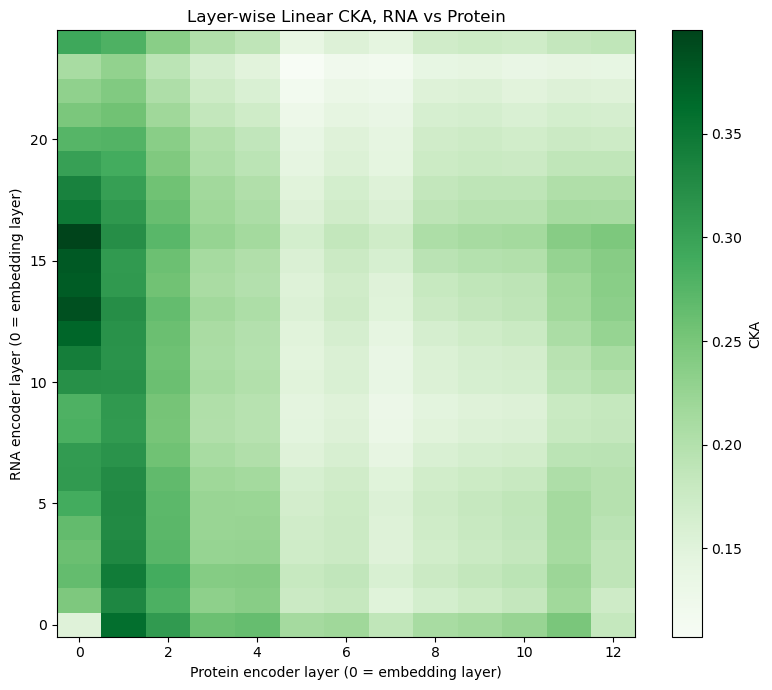

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cka_matrix, cmap="Greens", aspect="auto", origin="lower")
ax.set_xlabel("Protein encoder layer (0 = embedding layer)")
ax.set_ylabel("RNA encoder layer (0 = embedding layer)")
ax.set_title("Layer-wise Linear CKA, RNA vs Protein")
plt.colorbar(im, ax=ax, label="CKA")
plt.tight_layout()
plt.show()

The layer-wise breakdown confirms the RNA encoder has 24 transformer layers and the protein encoder has 12, matching both models' published architectures and confirming output_hidden_states captured every layer as intended. The final-layer CKA recomputed here on this 200-sequence subsample is 0.187, higher than the 0.128 computed earlier on the full 981-sequence sample. Since hidden_states[-1] is mathematically identical to the pooled output used in the earlier CKA cell, this gap reflects sampling noise from the much smaller subsample rather than a change in what is being measured, a reminder that CKA estimates at n=200 carry real variance and the exact heatmap values should be read as indicative rather than precise.

The overall peak is 0.400, at RNA layer 16 of 24 against protein layer 0, the protein encoder's embedding layer, before self-attention has mixed any context into it. Restricting the search to protein's contextualized layers only drops the peak to 0.359, and that second peak sits at RNA layer 0, the RNA encoder's own embedding layer, against protein layer 1, its first transformer layer. So the two strongest alignment points in the entire matrix both involve one encoder sitting at or immediately next to its embedding layer rather than two deeply contextualized representations meeting in the middle. Mean-pooled embedding layers are close to context-free composition summaries, nucleotide or amino acid identity and frequency, with no information about arrangement or learned function. This is consistent with the GC content probe result earlier in the notebook: genetic code redundancy means amino acid composition carries a real signature of the source gene's GC content, so a compositional signal on each side, not a deep semantic one, looks like the more likely driver of most of the measured cross-modal alignment here.

This tempers, without undoing, the fusion argument made after the CCA and retrieval results above. Compositional cross-modal correspondence is still real, documented biology and still worth a fusion mechanism being able to exploit, but it is a more modest claim than deep functional alignment between the two encoders' learned representations. The honest summary is that this pipeline has found a genuine but largely compositional bridge between RNA and protein embeddings, rather than evidence that the two encoders converge on shared higher order biological meaning.

# Stage 1, Track B: Cross-Modal Geometry, Mutual k-NN, CCA, and Retrieval

A second Track B geometry metric, testing whole-space similarity a different way than CKA: for each sequence, do its k nearest neighbors in RNA-embedding space overlap with its k nearest neighbors in protein-embedding space? mutual_knn_alignment computes that overlap fraction per sequence and averages across all of them. Unlike CKA, which compares the two spaces' overall linear structure, this is a purely local, non-parametric notion of similarity, useful as a second, differently-biased metric that should broadly agree with CKA if the CKA reading is real rather than an artifact of the linear-kernel assumption.

In [20]:
def mutual_knn_alignment(X, Y, k=10):
    n = X.shape[0]
    neighbors_x = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X, return_distance=False)
    neighbors_y = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y, return_distance=False)
    overlaps = [len(set(neighbors_x[i, 1:]) & set(neighbors_y[i, 1:])) / k for i in range(n)]
    return np.mean(overlaps)

score = mutual_knn_alignment(rna_embeds, prot_embeds, k=10)
print(f"Mutual k-NN alignment (k=10), RNA vs protein: {score:.3f}")
print(f"Chance level for {len(rna_embeds)} points: roughly {10/len(rna_embeds):.4f}")

Mutual k-NN alignment (k=10), RNA vs protein: 0.070
Chance level for 981 points: roughly 0.0102


The third and most consequential Track B method: rather than asking whether the two full embedding spaces agree overall, CKA, mutual k-NN, Canonical Correlation Analysis searches specifically for whatever narrow subspace is maximally correlated between them, which can exist even when the spaces disagree everywhere else. Both embedding spaces are first reduced to 50 principal components each, fit only on a training split, never the held-out test split used for evaluation, to avoid any leakage, then CCA finds 10 canonical component pairs on that training split and is evaluated purely on the held-out 30 percent test split, so the canonical correlations reported are a genuine out-of-sample result, not an in-sample fit. Cross-modal retrieval then asks a more task-grounded version of the same question directly in that learned subspace: given an RNA embedding, does a nearest-neighbor search in protein-embedding space recover the correct matching protein among its top few candidates, at a far higher rate than the tiny chance level for a held-out set this size?

In [21]:
train_idx, test_idx = train_test_split(np.arange(len(rna_embeds)), test_size=0.3, random_state=SEED)

pca_rna = PCA(n_components=50, random_state=SEED).fit(rna_embeds[train_idx])
pca_prot = PCA(n_components=50, random_state=SEED).fit(prot_embeds[train_idx])

rna_train_r, prot_train_r = pca_rna.transform(rna_embeds[train_idx]), pca_prot.transform(prot_embeds[train_idx])
rna_test_r, prot_test_r = pca_rna.transform(rna_embeds[test_idx]), pca_prot.transform(prot_embeds[test_idx])

cca = CCA(n_components=10).fit(rna_train_r, prot_train_r)
rna_test_c, prot_test_c = cca.transform(rna_test_r, prot_test_r)

print("Canonical correlations on held-out test data:")
for i in range(10):
    corr = np.corrcoef(rna_test_c[:, i], prot_test_c[:, i])[0, 1]
    print(f"  Component {i + 1}: {corr:.3f}")

n_test = len(test_idx)
nn = NearestNeighbors(n_neighbors=min(10, n_test)).fit(prot_test_c)
_, neighbor_idx = nn.kneighbors(rna_test_c)

print("\nCross-modal retrieval on held-out test data:")
for k in (1, 5, 10):
    correct = sum(i in neighbor_idx[i, :k] for i in range(n_test))
    print(f"  Recall@{k}: {correct / n_test:.3f} (chance level: {k / n_test:.4f})")

Canonical correlations on held-out test data:
  Component 1: 0.955
  Component 2: 0.914
  Component 3: 0.846
  Component 4: 0.872
  Component 5: 0.786
  Component 6: 0.772
  Component 7: 0.588
  Component 8: 0.670
  Component 9: 0.537
  Component 10: 0.584

Cross-modal retrieval on held-out test data:
  Recall@1: 0.366 (chance level: 0.0034)
  Recall@5: 0.614 (chance level: 0.0169)
  Recall@10: 0.759 (chance level: 0.0339)


Mutual k-nearest-neighbor overlap of 0.070, against a chance level of roughly 0.010 for this sample size, confirms the same modest but real global alignment CKA found, about seven times above what random embeddings would show. Read alongside CKA, both metrics agree that RNA and protein embeddings are only loosely related when compared as whole spaces.

The CCA and retrieval results tell a different, more encouraging part of the story, and reconcile with the synergy check above rather than contradicting it. Canonical correlations reach as high as 0.955 in the top component, computed on held-out data so this is not overfitting, and cross-modal retrieval built on that same learned subspace finds the correct matching protein embedding as the top candidate 36.6 percent of the time, against a chance level of 0.3 percent. CKA and mutual k-NN measure whether the two full representation spaces agree overall, treating every direction as equally important. CCA instead searches specifically for whatever narrow subspace is maximally correlated between the two spaces, even if that subspace is a small slice of each encoder's total variance. Together these results say RNA and protein embeddings are mostly encoding different things, consistent with the low CKA, but there is a specific, strong, learnable shared axis buried in both of them, plausibly the same compositional signal the GC content probe surfaced above. That explains why naive concatenation showed no synergy: concatenation does not know where to look for that shared axis, while CCA, given the freedom to search for it, finds it easily. This is the strongest argument in this Stage 1 pilot for why a trained fusion mechanism, rather than simple concatenation, is worth building: real cross-modal structure exists, it simply is not accessible without a method that can learn where to find it.

# Stage 1, Track B: Cross-Modal Geometry, UMAP (Qualitative Only)

A purely qualitative, visual complement to the quantitative Track B metrics above: UMAP projects the full RNA and full protein embedding spaces down to two dimensions each, separately, purely for the human eye to inspect overall cluster structure. This is explicitly the weakest form of evidence in Track B, a 2D projection can mislead in ways a numeric metric cannot, and is included for communicating results rather than as a claim in itself, which is why it comes after, not instead of, CKA, mutual k-NN, and CCA above.

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


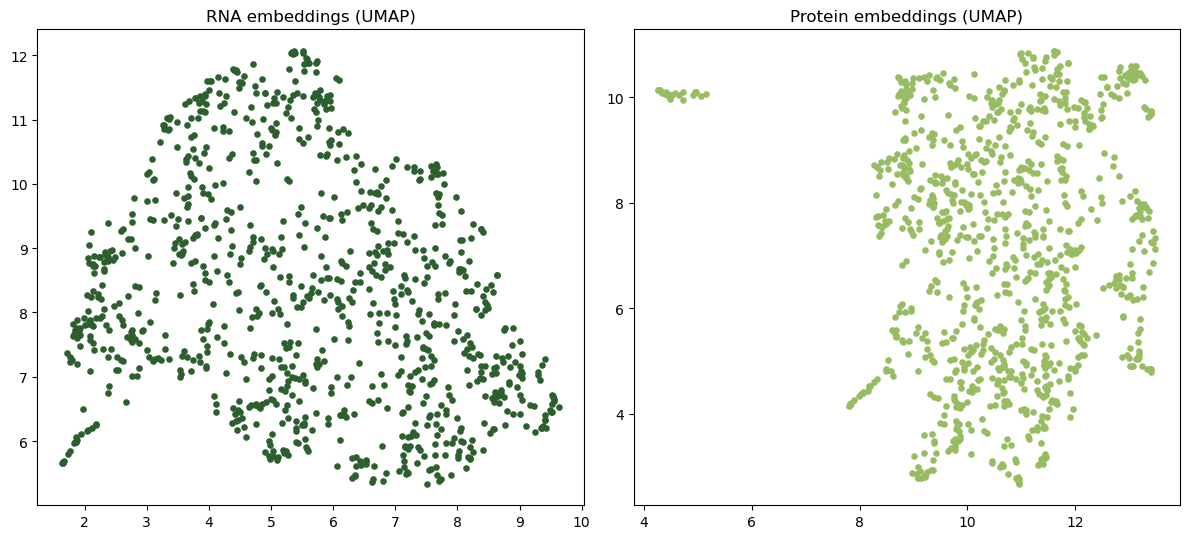

In [22]:
coords_rna = umap.UMAP(random_state=SEED).fit_transform(rna_embeds)
coords_prot = umap.UMAP(random_state=SEED).fit_transform(prot_embeds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].scatter(coords_rna[:, 0], coords_rna[:, 1], s=14, color="#2C5F2D")
axes[0].set_title("RNA embeddings (UMAP)")
axes[1].scatter(coords_prot[:, 0], coords_prot[:, 1], s=14, color="#97BC62")
axes[1].set_title("Protein embeddings (UMAP)")
plt.tight_layout()
plt.show()

Both RNA and protein embeddings show one large main cluster plus a small handful of points that separate out on their own. Two independently trained encoders isolating the same small subgroup is unlikely to be coincidental, and it may reflect a species subpopulation within this multi species dataset (human, mouse, frog, fish). This is illustrative rather than evidence on its own, but worth a follow up check against the dataset's species column if time allows.

# Stage 1, Pipeline Validation, Control Dataset Check (mRFP_Expression)

The pipeline-correctness control that everything above depends on being trustworthy. mRFP_Expression's defining property is that every one of its 1000 sequence variants is a synonymous recoding of one single gene, meaning they use different codons but must translate to the exact same protein sequence. This cell embeds that control dataset through the identical embed_dataset pipeline used for the main dataset, then checks two things a correct pipeline must produce: that every variant really does translate to one identical protein string, and that the resulting protein embeddings collapse almost to a single point, correctly seeing no difference, while the RNA embeddings, which do see the codon-level differences even though they don't change the protein, spread out, correctly seeing a difference that is really there.

In [23]:
print("Every variant here is a synonymous recoding of one gene, so they should")
print("all translate to the identical protein. This checks that the pipeline")
print("actually behaves that way before trusting results on the main dataset.\n")

control_df = pd.read_csv(CONTROL_CSV_PATH).dropna(subset=[SEQ_COLUMN]).sample(n=N_ROWS, random_state=SEED)
control_rna, control_prot, control_proteins, _ = embed_dataset(
    control_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN
)

unique_proteins = set(control_proteins)
print(f"Unique translated protein sequences across {len(control_proteins)} variants: {len(unique_proteins)}")
if len(unique_proteins) == 1:
    print("  As expected: every variant encodes the same protein.")
else:
    print("  Unexpected: variants encode different proteins. Check the frame and start codon on this file.")

if len(control_prot) > 1:
    protein_spread = np.linalg.norm(control_prot - control_prot.mean(axis=0), axis=1).mean()
    rna_spread = np.linalg.norm(control_rna - control_rna.mean(axis=0), axis=1).mean()
    print(f"  Average distance to centroid, protein embeddings: {protein_spread:.5f} (should be near zero)")
    print(f"  Average distance to centroid, RNA embeddings:     {rna_spread:.5f} (should be clearly nonzero)")

Every variant here is a synonymous recoding of one gene, so they should
all translate to the identical protein. This checks that the pipeline
actually behaves that way before trusting results on the main dataset.

Unique translated protein sequences across 1000 variants: 1
  As expected: every variant encodes the same protein.
  Average distance to centroid, protein embeddings: 0.00003 (should be near zero)
  Average distance to centroid, RNA embeddings:     4.72361 (should be clearly nonzero)


In this control run, all 1,000 sampled `mRFP_Expression` variants translated to one identical protein sequence. Their protein embeddings were nearly identical (mean distance to centroid $0.00003$), while the RNA embeddings varied (distance $4.72$). This supports the expected behavior for synonymous recodings: the nucleotide input changes while the translated protein input stays fixed.

The two embedding spaces have different dimensions and scales, so these raw distances are not a normalized comparison of information content. This control checks a specific translation/embedding behavior; it does not validate every frame assumption, stability score, or representation-analysis result on the main dataset.


# Stage 1, Track C: Interpretability, Overview

Track A studies which targets a simple model can decode from the frozen embeddings. Track B compares representation geometry. Track C explores whether aggregated attention is associated with candidate RNA motif positions, and whether a sample-level alignment measure is associated with prediction error.

These are exploratory diagnostics. A sequence-pattern match is not a validated regulatory site, attention is not a direct assay of regulatory function, and an alignment–error correlation does not measure the effect of adding an alignment loss. The results can motivate specific follow-up experiments; they do not select a fusion architecture by themselves.


# Stage 1, Track C: Interpretability, Attention Extraction From the Frozen Encoder

Tracks A and B only ever looked at the encoders' final pooled output vector, treating the model itself as a black box. This step opens the box: it reuses the already-loaded frozen RNA encoder, but requests `output_attentions=True` instead of `output_hidden_states=True`, mirroring the existing embedding pattern used everywhere above. The result is one attention tensor per transformer layer, each shaped (heads, sequence length, sequence length), recording how much of every token's representation was built from every other token. This is the raw material the rest of Track C compares against real regulatory motifs.

Recent `transformers` releases default many ESM-based architectures, including this RNA encoder, to the "sdpa" attention implementation, which cannot return per-head attention weights even when `output_attentions=True` is passed. Getting real output here requires a second copy of the model loaded with `attn_implementation="eager"`, kept as its own object (`rna_model_attn`) below so the already-computed Track A and Track B results, built on the original `rna_model`, are never touched.

In [24]:
def get_attention_maps(model, tokenizer, sequence, device="cpu"):
    """
    Runs one sequence through a frozen encoder and pulls its attention weights,
    mirroring your existing get_embeddings() pattern but with output_attentions=True
    instead of output_hidden_states=True.
    """
    inputs = tokenizer(sequence, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    # outputs.attentions is a tuple, one tensor per layer
    # each tensor's shape is (batch=1, num_heads, seq_len, seq_len)
    attentions = [layer_att.squeeze(0).cpu().numpy() for layer_att in outputs.attentions]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return attentions, tokens

In [25]:
rna_model_attn = AutoModel.from_pretrained(
    RNA_MODEL_NAME, trust_remote_code=True, attn_implementation="eager"
).to(DEVICE).eval()

Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-human-ref and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The load report below is the same kind of routine Hugging Face weight-loading confirmation seen when the encoders first loaded, here for this second, eager-attention copy specifically. Nothing in it indicates a problem: it lists the model's own untrained language-modeling head as unexpected, which is expected and irrelevant, since only its attention weights are used from here on.

# Stage 1, Track C: Interpretability, Aggregating Attention Into One Score Per Position

A single layer's attention is a full (heads x positions x positions) tensor, too much to interpret position by position. `aggregate_attention` collapses it to one score per token position by averaging across all attention heads within a chosen layer, then summing how much attention each position receives from every other position ("incoming" attention, as opposed to how much it sends out). A position many other positions rely on gets a high score. The score is min-max normalized to [0, 1] so it is comparable across sequences of different lengths. The default, `layer=-1`, uses the last transformer layer, since final layers tend to hold the most semantically refined attention.

That score is still indexed by token, not by raw nucleotide position, and the Nucleotide Transformer tokenizer groups several nucleotides into each token rather than mapping one to one. `expand_token_attention_to_nucleotides` corrects for that by repeating each token's score across the exact number of nucleotides it covers, read from the token's own string length rather than an assumed fixed group size, and dropping special tokens like `<cls>`. This is what puts attention scores on the same coordinate system as the motif hits found in the next step, which are found directly on the raw sequence.

In [26]:
def aggregate_attention(attentions, layer=-1, mode="incoming"):
    """
    layer=-1 uses the last layer, which tends to hold the most semantically
    refined attention. mode="incoming" measures, for each position, how much
    attention it RECEIVES from everywhere else, averaged across all heads.
    High incoming attention means many other positions rely on that spot,
    which is what you want if you're asking "is this position important".
    """
    layer_att = attentions[layer].mean(axis=0)  # average across heads -> (seq_len, seq_len)
    score = layer_att.sum(axis=0) if mode == "incoming" else layer_att.sum(axis=1)
    score = (score - score.min()) / (score.max() - score.min() + 1e-8)
    return score

In [27]:
def expand_token_attention_to_nucleotides(attn_score, tokens):
    """
    The RNA tokenizer likely groups multiple nucleotides into each token
    (commonly 6 at a time for Nucleotide Transformer), so token positions
    don't line up 1:1 with raw sequence positions. This repeats each real
    token's score across the nucleotides it actually covers (read directly
    from the token's own string length, so it's correct regardless of the
    exact tokenization scheme) and drops special tokens like <cls>.
    """
    expanded = []
    for score, tok in zip(attn_score, tokens):
        if tok.startswith("<") or tok.startswith("["):
            continue
        expanded.extend([score] * len(tok))
    return np.array(expanded)

# Stage 1, Track C: Interpretability, Motif Scanning (RNA Stability Elements)

This step creates **candidate sequence-pattern annotations** for an attention comparison. It replaces transcription-factor motifs from JASPAR with RNA-relevant patterns. That is a better match to the post-transcriptional question, but it does not create experimentally validated regulatory ground truth.

| Pattern | What the scan identifies | Interpretation limit |
|---|---|---|
| AUUUA | ARE-associated pentamer | A match alone does not establish an active AU-rich element or altered stability. |
| UUAUUUAUU | ARE-associated nonamer | Related to, and containing, the pentamer; these are not independent mechanistic classes. |
| DRACH | Consensus associated with candidate m6A sites | D = A/G/U, R = A/G, H = A/C/U. The central A is a potential methylation site; a match does not establish methylation. |

The ARE patterns have experimental precedent in [Zubiaga et al. (1995)](https://pmc.ncbi.nlm.nih.gov/articles/PMC230450/). Single-nucleotide mapping shows that only a subset of DRACH candidates are methylated; see [Linder et al. (2015)](https://pmc.ncbi.nlm.nih.gov/articles/PMC4487409/). Motif occurrence, molecular modification or binding, and a functional effect on stability are distinct claims.

The scan uses IUPAC consensus regexes without an external database call. These annotations depend only on sequence. The [CodonBERT source repository](https://github.com/Sanofi-Public/CodonBERT) links the stability task to [iCodon](https://www.nature.com/articles/s41598-022-15526-7), which focuses on coding-sequence codon composition. The exact region and label mapping for the local CSV still need verification; the columns do not establish UTR coverage. Absence or presence of these patterns therefore needs region-aware interpretation.


In [28]:
def iupac_to_regex(pattern):
    """Turns an IUPAC degenerate nucleotide pattern (e.g. "DRACH") into a
    regex character-class pattern (e.g. "[AGT][AG]AC[ACT]"), on the DNA
    alphabet so it lines up with the DNA-converted sequence used everywhere
    else in this notebook (rna_to_dna)."""
    IUPAC = {
        "A": "A", "C": "C", "G": "G", "T": "T", "U": "T",
        "R": "[AG]", "Y": "[CT]", "S": "[GC]", "W": "[AT]",
        "K": "[GT]", "M": "[AC]", "B": "[CGT]", "D": "[AGT]",
        "H": "[ACT]", "V": "[ACG]", "N": "[ACGT]",
    }
    return "".join(IUPAC[b] for b in pattern.upper())


def find_iupac_matches(sequence, iupac_pattern):
    """Every match of an IUPAC degenerate motif in the sequence, including
    overlapping matches (needed since class II AREs are defined by
    overlapping AUUUA repeats). Returns 0-based (start, end) positions."""
    seq = sequence.upper().replace("U", "T")
    regex = iupac_to_regex(iupac_pattern)
    length = len(iupac_pattern)
    return [(m.start(), m.start() + length) for m in re.finditer(f"(?={regex})", seq)]


# Real, literature-established RNA elements that govern post-transcriptional
# mRNA stability. See the markdown above for citations and the CDS-vs-UTR caveat.
STABILITY_MOTIFS = {
    "ARE_pentamer": "AUUUA",
    "ARE_nonamer": "UUAUUUAUU",
    "m6A_DRACH": "DRACH",
}


def scan_sequence_for_motifs(sequence, motifs=STABILITY_MOTIFS):
    """
    Returns (start, end, motif_name, score) for every hit, the same shape the
    JASPAR version returned, so attention_motif_overlap and
    plot_attention_with_motifs below need no changes. Score is fixed at 1.0:
    these are degenerate consensus matches (present or absent), not PSSM
    log-odds scores like JASPAR's were.
    """
    hits = []
    for name, pattern in motifs.items():
        for start, end in find_iupac_matches(sequence, pattern):
            hits.append((start, end, name, 1.0))
    return hits

# Stage 1, Track C: Interpretability, Attention-Motif Overlap Test

This exploratory comparison asks whether nucleotide-level attention scores are higher at the candidate motif positions than elsewhere. The existing one-sided Mann–Whitney U test is run for the pooled motif mask and separately for each pattern under `by_motif`. The ARE pentamer and nonamer are related patterns; the DRACH mask marks methylation candidates, not measured m6A sites.

Treat the returned p-values as **nominal**. The implementation expands token scores across nucleotides, repeating values; neighboring positions are dependent, and many sequence/pattern comparisons are performed without multiplicity correction. Sequence composition and tokenization can also affect both masks and scores. Consequently, a small p-value or a higher motif mean would identify a candidate association for follow-up, not establish that the encoder learned functional RNA regulation. Calibrated null models and a suitable experimental annotation would require a separate methodological proposal.


In [29]:
def attention_motif_overlap(attention_score, motif_hits):
    """
    Compares attention scores at motif-hit positions against everywhere else,
    both pooled across all motif classes and broken out per motif class,
    since ARE and m6A sites work through different mechanisms and a
    pooled-only result can hide a real effect specific to one of them.
    """
    def _test(positions):
        non_positions = set(range(len(attention_score))) - positions
        if not positions or not non_positions:
            return None
        at = attention_score[list(positions)]
        off = attention_score[list(non_positions)]
        stat, pval = mannwhitneyu(at, off, alternative="greater")
        return {
            "mean_attention_at_motifs": at.mean(),
            "mean_attention_elsewhere": off.mean(),
            "n_motif_positions": len(positions),
            "p_value": pval,
        }

    all_positions = set()
    by_name = {}
    for start, end, name, score in motif_hits:
        positions = set(range(start, min(end, len(attention_score))))
        all_positions.update(positions)
        by_name.setdefault(name, set()).update(positions)

    result = _test(all_positions)
    if result is None:
        return None
    result["by_motif"] = {name: _test(positions) for name, positions in by_name.items()}
    return result

# Stage 1, Track C: Interpretability, Visualizing Examples

Turns one sequence's aggregated attention score (Step 2) and motif hits (Step 3) into a single annotated plot: the attention score drawn as a line across sequence position, with each motif hit overlaid as a shaded, color-coded band by motif class and a legend, rather than repeated per-hit text labels, which become unreadable once hits cluster densely, as the JASPAR version's plot did. This is a qualitative companion to the statistical test in Step 4, an actual picture showing individual examples of whether high-attention regions visually coincide with real motif locations.

In [30]:
MOTIF_COLORS = {
    "ARE_pentamer": "#97BC62",
    "ARE_nonamer": "#2C5F2D",
    "m6A_DRACH": "#6B6B63",
}

def plot_attention_with_motifs(attention_score, motif_hits, title=""):
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(attention_score, color="black", linewidth=1)
    ax.fill_between(range(len(attention_score)), attention_score, color="gray", alpha=0.15)
    seen = set()
    for start, end, name, score in motif_hits:
        color = MOTIF_COLORS.get(name, "gray")
        ax.axvspan(start, end, color=color, alpha=0.35, label=name if name not in seen else None)
        seen.add(name)
    ax.set_xlabel("Sequence position")
    ax.set_ylabel("Attention score (normalized)")
    ax.set_title(title)
    if seen:
        ax.legend(loc="upper right", fontsize=8, ncol=len(seen))
    plt.tight_layout()
    plt.show()

# Stage 1, Track C: Interpretability, Running the Attention-Motif Analysis

With every piece defined above, this runs the actual analysis in two passes. First, a single-example sanity check on one sequence, printing the number of motif hits found, confirming the attention array and sequence length now agree after the nucleotide-level expansion, and producing one look at the Step 5 visualization. Second, the same pipeline run across the first 100 kept sequences, summarizing how often attention is significantly higher at motif positions (p < 0.05) and the average size of that gap. That summary across many sequences, not the single example, is the real evidence for or against the attention-motif interpretability finding.

Found 63 motif hits in this sequence, sequence length 2556, attention array length 2556
{'mean_attention_at_motifs': 0.003097159, 'mean_attention_elsewhere': 0.003254782, 'n_motif_positions': 311, 'p_value': 0.603333601449868, 'by_motif': {'ARE_pentamer': {'mean_attention_at_motifs': 0.0022527578, 'mean_attention_elsewhere': 0.0032472762, 'n_motif_positions': 30, 'p_value': 0.9596897946285903}, 'm6A_DRACH': {'mean_attention_at_motifs': 0.003168084, 'mean_attention_elsewhere': 0.003244043, 'n_motif_positions': 284, 'p_value': 0.42673978168547777}}}


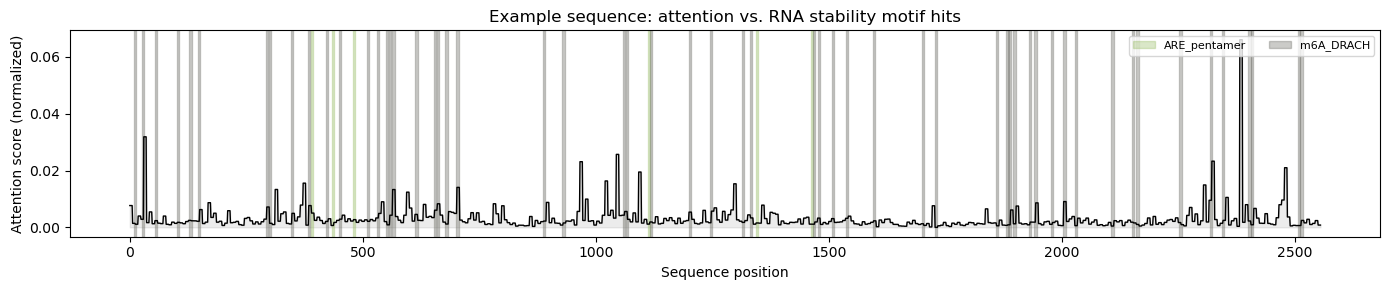

In [31]:
# Single-example sanity check
sample_seq = kept_seqs[0]
rna_dna_seq = rna_to_dna(sample_seq)

attentions, tokens = get_attention_maps(rna_model_attn, rna_tok, rna_dna_seq, device=DEVICE)
attn_score_tokens = aggregate_attention(attentions, layer=-1, mode="incoming")
attn_score = expand_token_attention_to_nucleotides(attn_score_tokens, tokens)

motif_hits = scan_sequence_for_motifs(sample_seq)
print(f"Found {len(motif_hits)} motif hits in this sequence, sequence length {len(sample_seq)}, attention array length {len(attn_score)}")

result = attention_motif_overlap(attn_score, motif_hits)
print(result)

plot_attention_with_motifs(attn_score, motif_hits, title="Example sequence: attention vs. RNA stability motif hits")

This example contains 63 candidate ARE-pentamer or DRACH matches, covering 311 of 2,556 positions. Mean attention is $0.0031$ at matched positions and $0.0033$ elsewhere, with nominal one-sided $p = 0.60$.

The ARE-pentamer mask covered 30 positions (nominal $p = 0.96$), and the DRACH mask covered 284 (nominal $p = 0.43$). Masks can overlap, so the per-pattern counts need not sum to the pooled count. This example shows no higher mean attention at the scanned positions under the current aggregation. It does not establish a biological null: the patterns are candidate annotations, and the positional test has the dependence and calibration limitations described above. The plot shows the same exploratory comparison.


In [32]:
overlap_results = []
for seq in kept_seqs[:100]:
    dna_seq = rna_to_dna(seq)
    attentions, tokens = get_attention_maps(rna_model_attn, rna_tok, dna_seq, device=DEVICE)
    attn_tokens = aggregate_attention(attentions, layer=-1, mode="incoming")
    attn = expand_token_attention_to_nucleotides(attn_tokens, tokens)
    hits = scan_sequence_for_motifs(seq)
    r = attention_motif_overlap(attn, hits)
    if r is not None:
        overlap_results.append(r)

sig_fraction = sum(r["p_value"] < 0.05 for r in overlap_results) / len(overlap_results)
mean_gap = np.mean([r["mean_attention_at_motifs"] - r["mean_attention_elsewhere"] for r in overlap_results])
print(f"Sequences with usable motif hits: {len(overlap_results)} of 100")
print(f"Fraction with significantly higher attention at motif positions (p < 0.05): {sig_fraction:.2f}")
print(f"Mean attention gap (at motifs minus elsewhere): {mean_gap:.4f}")

# Per-motif-class breakdown: ARE-mediated and m6A-mediated decay work through
# different mechanisms, so this checks whether either shows a real effect that
# the pooled numbers above could be diluting.
for motif_name in STABILITY_MOTIFS:
    per_motif = [r["by_motif"][motif_name] for r in overlap_results if r["by_motif"].get(motif_name) is not None]
    if not per_motif:
        print(f"{motif_name}: no usable hits across these 100 sequences")
        continue
    sig = sum(m["p_value"] < 0.05 for m in per_motif) / len(per_motif)
    gap = np.mean([m["mean_attention_at_motifs"] - m["mean_attention_elsewhere"] for m in per_motif])
    print(f"{motif_name}: {len(per_motif)} sequences with hits, {sig:.2f} significant fraction, mean gap {gap:.4f}")

Sequences with usable motif hits: 100 of 100
Fraction with significantly higher attention at motif positions (p < 0.05): 0.07
Mean attention gap (at motifs minus elsewhere): -0.0009
ARE_pentamer: 41 sequences with hits, 0.05 significant fraction, mean gap -0.0027
ARE_nonamer: no usable hits across these 100 sequences
m6A_DRACH: 100 sequences with hits, 0.08 significant fraction, mean gap -0.0009


Every sequence in the 100-sequence run has at least one usable pattern match. The summaries are:

| Pattern set | Sequences with usable matches | Fraction with nominal $p < 0.05$ | Mean attention gap (matched minus other positions) |
|---|---:|---:|---:|
| Pooled patterns | 100 | 7% | −0.0009 |
| ARE pentamer | 41 | 5% | −0.0027 |
| ARE nonamer | 0 | Not available | Not available |
| DRACH | 100 | 8% | −0.0009 |

These summaries show no positive average attention gap for the observed pattern sets. The 7% threshold fraction cannot be treated as a calibrated comparison with a 5% chance rate: positional dependence, repeated token scores, overlapping patterns, and multiple tests remain unaddressed. No usable nonamer hits means that pattern was not evaluated in this sample.

The evidence is limited to these candidate patterns, sequences, and the current attention aggregation. It does not establish absence of regulatory knowledge, validated absence of enrichment, or a publishable biological null. Confirming sequence-region coverage, experimentally supported sites, and an appropriate null comparison are possible follow-up decisions.


# Stage 1, Track C: Interpretability, Alignment–Error Association (Diagnostic for Stage 2)

This is an **exploratory sample-level adaptation** inspired by [Tjandrasuwita et al. (ICML 2025)](https://proceedings.mlr.press/v267/tjandrasuwita25a.html), not a replication of the paper's alignment–performance diagnostic. The paper relates alignment and performance across models/configurations and separately studies a contrastive-training intervention. The present code relates two quantities across examples from one fixed encoder pair.

For each example, local alignment is the cosine similarity between the RNA and protein vectors after CCA projection. A linear model uses their concatenation to predict stability in five folds; each example receives an absolute prediction error from the fold in which it was held out. Spearman correlation then measures the rank association between local alignment and those errors. It is a correlation, not a fitted slope; the existing function name is retained for compatibility.

A negative correlation would mean that more aligned examples tend to have smaller errors under this procedure. A near-zero value means no detected monotonic association. Neither result estimates the causal effect of adding an alignment loss, nor establishes modality uniqueness. That architecture question requires a controlled training comparison, with the evaluation and repeated-sequence issues resolved.


In [33]:
def compute_alignment_performance_slope(rna_cca, protein_cca, stability_labels, n_folds=5):
    """Correlate sample-level CCA cosine similarity with out-of-fold error.

    Inputs are paired CCA-projected rows and their matching stability labels.
    This exploratory rank association adapts the paper's motivation; it is
    not its across-model alignment-performance slope or an alignment-loss test.
    """
    local_alignment = np.array([
        cosine_similarity(rna_cca[i:i+1], protein_cca[i:i+1])[0, 0]
        for i in range(len(stability_labels))
    ])

    fused = np.concatenate([rna_cca, protein_cca], axis=1)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    errors = np.zeros(len(stability_labels))
    for train_idx, test_idx in kf.split(fused):
        reg = LinearRegression().fit(fused[train_idx], stability_labels[train_idx])
        errors[test_idx] = np.abs(reg.predict(fused[test_idx]) - stability_labels[test_idx])

    slope_corr, p_value = spearmanr(local_alignment, errors)
    return {
        "spearman_corr_alignment_vs_error": slope_corr,
        "p_value": p_value,
        "interpretation": (
            "A negative correlation associates higher sample-level alignment "
            "with lower prediction error under this procedure. A near-zero "
            "value indicates no detected monotonic association. This "
            "exploratory adaptation does not establish modality uniqueness "
            "or predict the effect of training with an alignment loss."
        )
    }

# Stage 1, Track C: Interpretability, Representational Similarity Analysis (RSA)

Representational similarity analysis (RSA) compares each modality's internal geometry. It computes correlation distances between pairs of examples within each embedding space, then correlates the two resulting distance vectors with Spearman correlation. The original feature dimensions may differ: corresponding entries in the distance vectors refer to the same example pairs.

This complements the other geometry summaries, but uses the same underlying data and is not independent confirmation of their conclusions. Pairwise distances share examples, so the entries are statistically dependent; the default Spearman p-value should be treated as nominal. The coefficient describes agreement between these distance structures, without establishing a particular shared subspace or a biological mechanism.


In [34]:
def compute_rsa(embeddings_a, embeddings_b):
    dist_a = pdist(embeddings_a, metric="correlation")
    dist_b = pdist(embeddings_b, metric="correlation")
    return spearmanr(dist_a, dist_b)

# Stage 1, Track C: Interpretability, Running the Alignment Diagnostics

Runs the sample-level alignment–error association on the held-out CCA vectors and matching labels, and RSA on the RNA and protein embeddings. These results summarize associations under the existing procedure. Together with the attention analysis, they can suggest follow-up hypotheses; they do not determine whether Stage 2 needs an alignment loss.


In [35]:
slope_result = compute_alignment_performance_slope(rna_test_c, prot_test_c, labels[test_idx])
print(slope_result)

rsa_score, rsa_pval = compute_rsa(rna_embeds, prot_embeds)
print(f"RSA (Spearman correlation of distance structures): {rsa_score:.3f}, p = {rsa_pval:.4g}")

{'spearman_corr_alignment_vs_error': -0.012889959728224883, 'p_value': 0.8255117133708139, 'interpretation': 'A negative correlation associates higher sample-level alignment with lower prediction error under this procedure. A near-zero value indicates no detected monotonic association. This exploratory adaptation does not establish modality uniqueness or predict the effect of training with an alignment loss.'}
RSA (Spearman correlation of distance structures): 0.234, p = 0


**Results.** The sample-level alignment–error Spearman correlation is $-0.013$, with nominal $p = 0.83$. No monotonic association was detected under this procedure. This is not the paper's across-model slope, evidence of high modality uniqueness, or a test showing that an alignment loss will help or hurt. The choice of alignment objective remains open.

RSA yielded a Spearman correlation of $0.234$, with nominal $p < 0.001$. The positive coefficient describes modest agreement in the two pairwise-distance structures. Because distances share examples and the analysis reuses the embeddings from the other diagnostics, the p-value is not a calibrated independent confirmation of a CCA subspace. A suitable permutation or other dependence-aware analysis would be a separate methodological change.
